# linear_dynamics plot

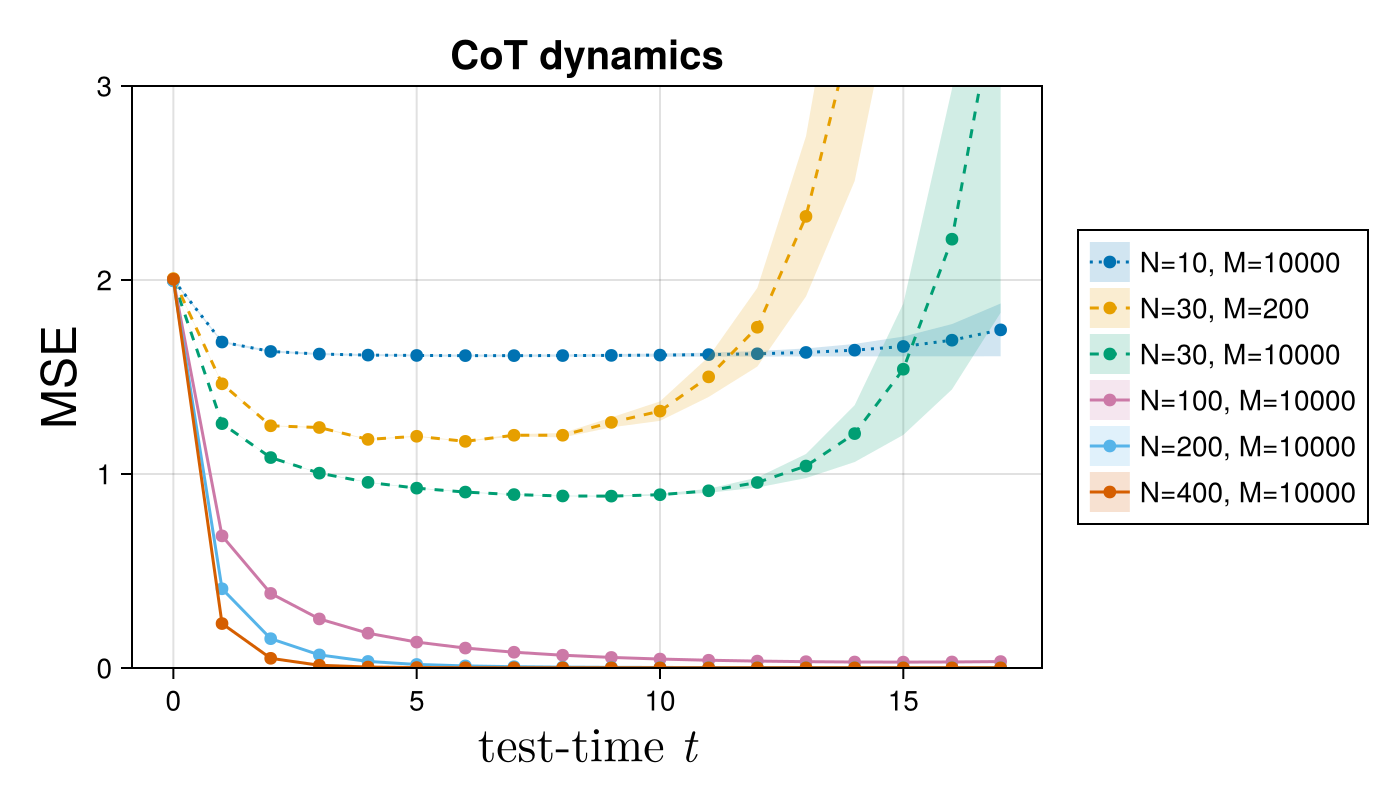

In [31]:
using CairoMakie
using CSV
using DataFrames

base_dir = "/home/takanami/cot_asymptotics/linear_dynamics"
results_root = joinpath(base_dir, "results")
dirs = filter(d -> startswith(d, "linear_dynamics_"), readdir(results_root))
isempty(dirs) && error("No results directory found in: $(results_root)")
latest_dir = joinpath(results_root, sort(dirs)[end])

df = CSV.read(joinpath(latest_dir, "summary.csv"), DataFrame)

pairs = sort(unique(select(df, [:n, :m])))
fig = Figure(size = (700, 400))
ax = Axis(
    fig[1, 1],
    xlabel = L"test-time $t$",
    ylabel = "MSE",
    title = "CoT dynamics",
    #yscale = log10,
    limits = (nothing, nothing, 0.0, 3.0),
    xlabelsize = 24,
    ylabelsize = 24,
    titlesize = 20,
)

colors = Makie.wong_colors()
for (k, row) in enumerate(eachrow(pairs))
    if (row.n, row.m) == (600, 10000) || (row.n, row.m) == (800, 10000)
        continue
    end

    # type 
    type = nothing
    if (row.n, row.m) == (10, 10000)
        type = "saturation"
        linetype = :dot   
    elseif (row.n, row.m) == (30, 200) || (row.n, row.m) == (30, 10000)
        type = "overthinking"
        linetype = :dash
    else
        type = "decay"
        linetype = :solid
    end


    sub = sort(df[(df.n .== row.n) .& (df.m .== row.m), :], :t)
    t = Float64.(sub.t)
    meanv = Float64.(sub.mean_loss)
    sev = Float64.(sub.se_loss)
    lower = max.(meanv .- sev, eps(Float64))
    upper = meanv .+ sev
    c = colors[mod1(k, length(colors))]
    t_end = 18


    band!(ax, t[1:t_end], lower[1:t_end], upper[1:t_end], color = (c, 0.18), label = "N=$(row.n), M=$(row.m)")
    lines!(ax, t[1:t_end], meanv[1:t_end], color = c, linestyle = linetype, label = "N=$(row.n), M=$(row.m)")
    scatter!(ax, t[1:t_end], meanv[1:t_end], color = c, label = "N=$(row.n), M=$(row.m)")
end

Legend(fig[1, 2], ax, merge=true)
fig